In [241]:
import pandas as pd
import numpy as np

In [242]:
df = pd.read_csv('bestsellers with categories.csv')
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [243]:
df.shape

(550, 7)

In [244]:
df.nunique()

Name           351
Author         248
User Rating     14
Reviews        346
Price           40
Year            11
Genre            2
dtype: int64

In [245]:
books_wo_nulls = df.dropna(subset=['Name','Author'])
books_duples_count = books_wo_nulls.duplicated(subset=['Name','Author']).sum()
books_unique_count = books_wo_nulls.drop_duplicates(subset=['Name','Author']).shape[0]
books_unique_count
# Відповідь: Про скільки книг зберігає дані датасет?: 351
# PS. Я вважаю, що книгу характерізує тільки назва та автор, перевидання та ціна продажу тут не враховуються

351

In [246]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
df.head()

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [247]:
df.isna().sum()
# Відповідь: Чи є в якихось змінних пропуски? (Так / ні): ні

name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64

In [248]:
df['genre'].unique()
# Відповідь: Які є унікальні жанри?: 'Non Fiction', 'Fiction'

array(['Non Fiction', 'Fiction'], dtype=object)

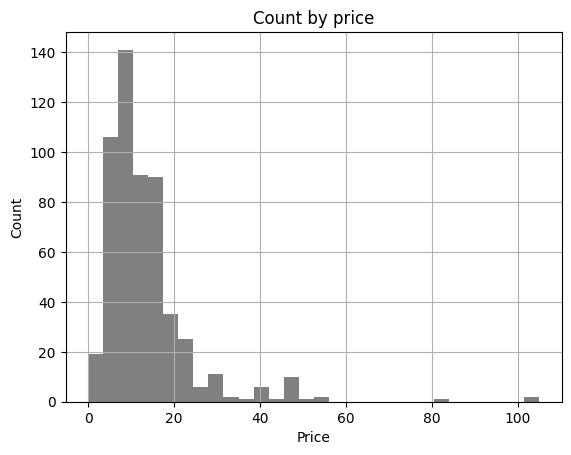

In [403]:
import matplotlib.pyplot as plt

df['price'].hist(bins=30, color = 'grey')
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Count by price')
plt.show()

In [250]:
df.dropna().duplicated(subset=['name', 'author','year','price']).sum()

np.int64(0)

In [251]:
df['price'].max()

np.int64(105)

In [252]:
df['price'].min()

np.int64(0)

In [253]:
df['price'].mean()

np.float64(13.1)

In [254]:
df['price'].median()

np.float64(11.0)

In [255]:
# Відповідь: Максимальна ціна?: 105
# Відповідь: Мінімальна ціна?: 0
# Відповідь: Середня ціна?: 13.1
# Відповідь: Медіанна ціна?: 11.0

In [256]:
max_rating = df['user_rating'].max()
# Відповідь: Який рейтинг у датасеті найвищий?: 4.9

In [275]:
df_unique = df.dropna(subset=['name','author']).drop_duplicates(subset=['name','author'])
(df_unique['user_rating'] == max_rating).sum()
# Відповідь: Скільки книг мають такий рейтинг?: 28

np.int64(28)

In [286]:
max_reviews = df['reviews'].max()
max_reviews
df[df['reviews'] == max_reviews]
# Відповідь: Яка книга має найбільше відгуків?: Where the Crawdads Sing by Delia Owens

,name,author,user_rating,reviews,price,year,genre
534,Where the Crawdads Sing,Delia Owens,4.8,87841,15,2019,Fiction


In [299]:
df_2015 = df[df['year'] == 2015]
max_price_2015 = df_2015['price'].max()
(df_2015['price'] == max_price_2015).sum()
df_2015.loc[df_2015['price'].idxmax()]
# Відповідь: З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча (можна використати проміжний датафрейм)?: Publication Manual of the American Psychologic...

name           Publication Manual of the American Psychologic...
author                        American Psychological Association
user_rating                                                  4.5
reviews                                                     8580
price                                                         46
year                                                        2015
genre                                                Non Fiction
Name: 277, dtype: object

In [315]:
fic_2010_count = len(df[(df['year'] == 2010) & (df['genre'] == 'Fiction')].dropna(subset=['name','author']).drop_duplicates(subset=['name','author']))
fic_2010_count

# Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році (використовуйте &)?: 20

20

In [325]:
rate_4_9_2010_2011_count = df[(df['year'].isin([2010,2011]))&(df['user_rating']==4.9)].shape[0]
rate_4_9_2010_2011_count

# Відповідь: Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках (використовуйте | або функцію isin)?: 1

1

In [330]:
df_2015_cheaper_8_usd = df[(df['year'] == 2015) & (df['price'] < 8)].sort_values(by = 'price')
df_2015_cheaper_8_usd 

# І насамкінець, давайте відсортуємо за зростанням ціни всі книги, які потрапили до рейтингу в 2015 році і коштують дешевше за 8 доларів (використовуйте функцію sort_values
# Яка книга остання у відсортованому списку? Відповідь: Old School (Diary of a Wimpy Kid #10)	

,name,author,user_rating,reviews,price,year,genre
507,To Kill a Mockingbird,Harper Lee,4.8,26234,0,2015,Fiction
54,Creative Haven Creative Cats Coloring Book (Ad...,Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
206,Knock-Knock Jokes for Kids,Rob Elliott,4.5,3673,4,2015,Non Fiction
111,First 100 Words,Roger Priddy,4.7,17323,4,2015,Non Fiction
210,Laugh-Out-Loud Jokes for Kids,Rob Elliott,4.6,6990,4,2015,Non Fiction
123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
55,Creative Haven Owls Coloring Book (Adult Color...,Marjorie Sarnat,4.8,3871,5,2015,Non Fiction
63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
224,Love You Forever,Robert Munsch,4.8,18613,5,2015,Fiction
478,The Very Hungry Caterpillar,Eric Carle,4.9,19546,5,2015,Fiction


In [336]:
svod_genre = df.groupby('genre').agg(max_price = ('price', 'max'), min_price = ('price', 'min'))
svod_genre
# Відповідь: Максимальна ціна для жанру Fiction: 82
# Відповідь: Мінімальна ціна для жанру Fiction: 0
# Відповідь: Максимальна ціна для жанру Non Fiction: 105
# Відповідь: Мінімальна ціна для жанру Non Fiction: 0

,max_price,min_price
genre,,
Fiction,82,0
Non Fiction,105,0


In [355]:
svod_authors1 = df.groupby('author').agg(books_count = ('name', 'count'), books_distinct_count=(('name', 'nunique'))).sort_values('books_distinct_count', ascending=False)
svod_authors1
# Доцільно рахувати кількість книг за унікальними назвами, щоб виключити перевидання 
# Відповідь: Якої розмірності вийшла таблиця?: (248, 2)         
# Відповідь: Який автор має найбільше книг?: Jeff Kinney	
# Відповідь: Скільки книг цього автора?: 12

,books_count,books_distinct_count
author,,
Jeff Kinney,12,12
Rick Riordan,11,10
Stephenie Meyer,7,7
Bill O'Reilly,7,6
J.K. Rowling,6,6
...,...,...
Tucker Carlson,1,1
W. Cleon Skousen,1,1
William Davis,2,1


In [405]:
svod_authors2 = df.groupby('author').agg(avr_rate = ('user_rating','mean')).sort_values('avr_rate')
svod_authors2 
svod_authors2[svod_authors2['avr_rate'] == svod_authors2['avr_rate'].min()]
# Відповідь: У якого автора середній рейтинг мінімальний?: Donna Tartt
# Відповідь: Який у цього автора середній рейтинг?: 3.9

,avr_rate
author,
Donna Tartt,3.9


In [378]:
joint_svod = pd.concat([svod_authors1, svod_authors2], axis=1).sort_values(by=['books_distinct_count', 'avr_rate'])
joint_svod
# Відповідь: Який автор перший у списку? Muriel Barbery по каунту, але по дистинкту - Donna Tartt

,books_count,books_distinct_count,avr_rate
author,,,
Donna Tartt,2,1,3.900000
Gillian Flynn,3,1,4.000000
Gallup,9,1,4.000000
Muriel Barbery,1,1,4.000000
Chris Cleave,1,1,4.100000
...,...,...,...
Bill O'Reilly,7,6,4.642857
Dav Pilkey,7,6,4.900000
Stephenie Meyer,7,7,4.657143


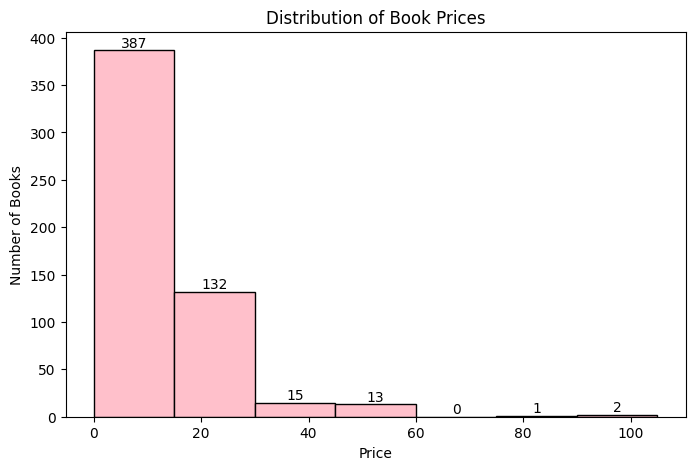

In [387]:
%matplotlib inline

plt.figure(figsize=(8,5))

counts, bins, patches = plt.hist(df['price'], bins=7, color='pink',edgecolor='black')
plt.bar_label(patches) # підписи
plt.title('Distribution of Book Prices')
plt.xlabel('Price')
plt.ylabel('Number of Books')

plt.show()

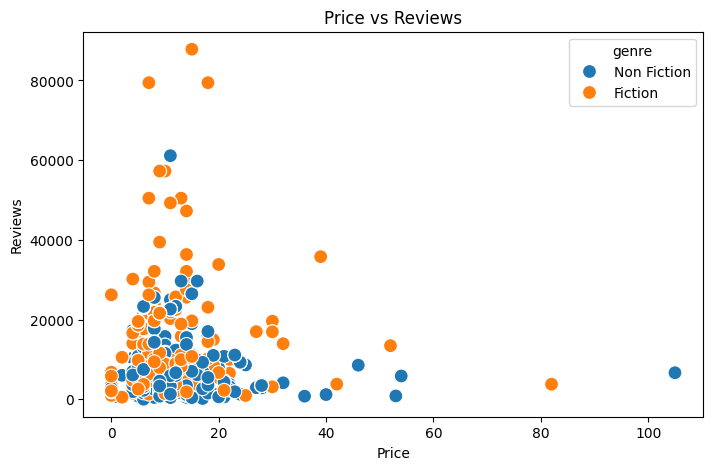

In [388]:
import seaborn as sns
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='price', y='reviews', hue='genre', s=100)
plt.title('Price vs Reviews')
plt.xlabel('Price')
plt.ylabel('Reviews')

plt.show()

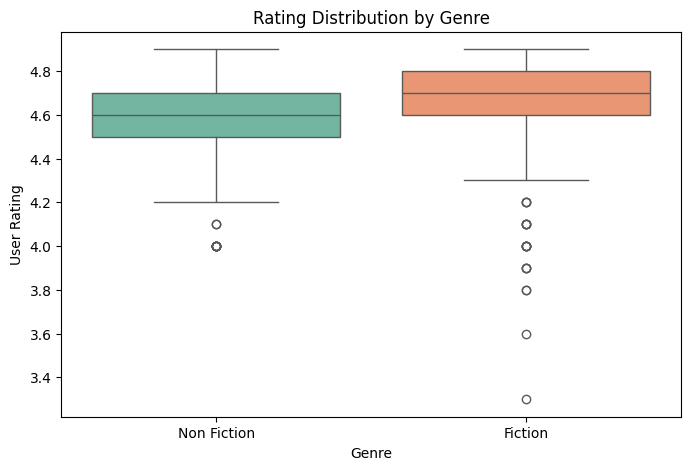

In [398]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='genre', y='user_rating', hue='genre', palette="Set2")
plt.title('Rating Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('User Rating')
plt.show()